In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# =====================================
# 📘 KNN Classification with KMeans-SMOTE
# =====================================

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import KMeansSMOTE

In [3]:
# =======================
# === Block 1: Load Data
# =======================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [4]:
# ==============================
# === Block 2: Split Features
# ==============================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

In [5]:
# =====================================
# === Block 3: Apply KMeans-SMOTE
# =====================================
from collections import Counter

print("\nBefore KMeans-SMOTE:", Counter(y_train))

# ✅ ปรับค่า cluster_balance_threshold เพื่อให้รองรับ class ที่มีตัวอย่างน้อย
kmeans_smote = KMeansSMOTE(
    random_state=42,
    cluster_balance_threshold=0.01
)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

print("\nAfter KMeans-SMOTE:", Counter(y_resampled))


Before KMeans-SMOTE: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})

After KMeans-SMOTE: Counter({4: 128807, 1: 128806, 3: 128805, 2: 128805, 5: 128801})


In [6]:
# ==========================================
# === Block 4: 10-Fold Cross Validation (with Mean ± SD)
# ==========================================
from sklearn.metrics import classification_report

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("=== 10-Fold Cross Validation Results ===")

# ✅ แปลงเป็น numpy array
X_resampled = np.array(X_resampled)
y_resampled = np.array(y_resampled)
classes = np.unique(y_resampled)

start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_tr, y_val = y_resampled[train_idx], y_resampled[val_idx]

    model = KNeighborsClassifier(n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    y_val_bin = label_binarize(y_val, classes=sorted(classes))
    y_pred_bin = label_binarize(y_pred, classes=sorted(classes))
    fold_auc = roc_auc_score(y_val_bin, y_pred_bin, average="weighted", multi_class="ovr")

    results.append([fold, acc, prec, rec, f1, fold_auc])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(fold_auc)

# === สรุปตาราง ===
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print(cv_df)

# === ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน ===
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")



=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.861202   0.862501  0.861202  0.860520  0.913252
1     2  0.859292   0.860685  0.859292  0.858635  0.912058
2     3  0.856466   0.857665  0.856466  0.855637  0.910291
3     4  0.856870   0.858384  0.856870  0.856239  0.910544
4     5  0.857924   0.859226  0.857924  0.857301  0.911202
5     6  0.858141   0.859583  0.858141  0.857417  0.911338
6     7  0.857924   0.859368  0.857924  0.857177  0.911202
7     8  0.858048   0.859586  0.858048  0.857469  0.911280
8     9  0.857660   0.859108  0.857660  0.857042  0.911037
9    10  0.858048   0.859365  0.858048  0.857345  0.911280

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.858 ± 0.001
Precision: 0.860 ± 0.001
Recall   : 0.858 ± 0.001
F1-score : 0.857 ± 0.001
AUC-ROC  : 0.911 ± 0.001

⏱ Completed in 221.12 seconds


In [10]:
# 💾 (optional) บันทึก mean+sd ลงไฟล์ csv
import os

cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSD/'
summary_path = base_path + "KNN_mean_sd.csv"

# ✅ ตรวจสอบและสร้างโฟลเดอร์ก่อนบันทึก (สำคัญมาก)
os.makedirs(base_path, exist_ok=True)

# 💾 บันทึกไฟล์ mean+sd summary
cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/MeanSD/KNN_mean_sd.csv


In [11]:
# =====================================
# === Block 5: Final Testing & Report
# =====================================
from sklearn.metrics import classification_report

model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(classes))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(classes))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="weighted", multi_class="ovr")

# === แสดงผลรวม ===
print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

# === Classification Report ===
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

# === Confusion Matrix ===
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



📈 Test Set Metrics:
Accuracy: 0.703, Precision: 0.721, Recall: 0.703, F1: 0.709, AUC: 0.818

Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.80      0.79     16078
           2       0.38      0.39      0.39      8376
           3       0.32      0.48      0.39      7486
           4       0.67      0.55      0.60     18265
           5       0.90      0.88      0.89     32201

    accuracy                           0.70     82406
   macro avg       0.61      0.62      0.61     82406
weighted avg       0.72      0.70      0.71     82406

Confusion Matrix:
[[12905  1922  1073   131    47]
 [ 2613  3252  2115   372    24]
 [  726  1833  3580  1218   129]
 [  459  1275  3706 10007  2818]
 [   93   178   591  3140 28199]]


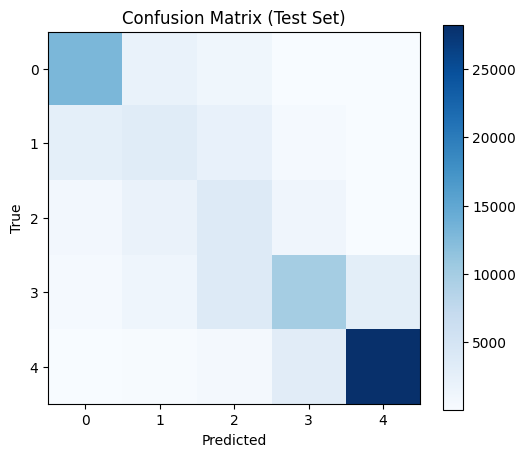

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


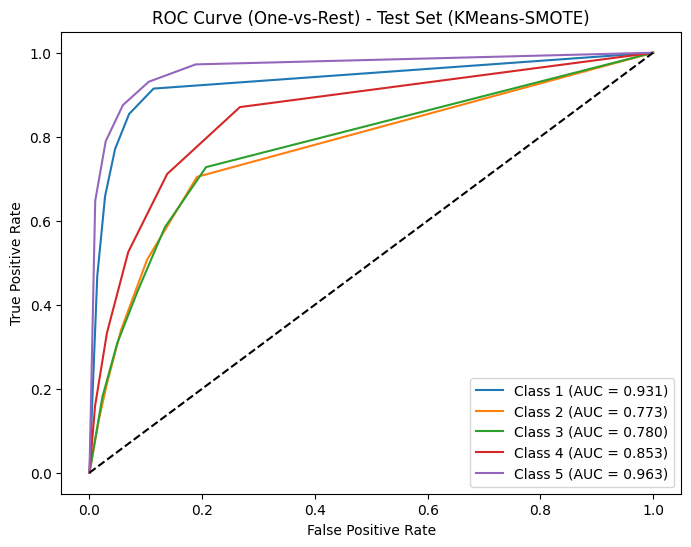

In [12]:
# ==========================================
# === Block6: Confusion Matrix & ROC Curve ===
# ==========================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# --- 2) ROC Curve (One-vs-Rest) ---
classes = model.classes_     # ✅ ใช้ชื่อโมเดลจริงที่เทรนไว้
n_classes = len(classes)

# แปลง y_test เป็น one-hot
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ probability จากโมเดล
y_pred_proba_test = model.predict_proba(X_test)

# คำนวณ fpr, tpr, auc
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 3) พล็อต ROC ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set (KMeans-SMOTE)')
plt.legend()
plt.show()

In [ ]:
# =====================================
# === Block 7: Save Model & AUC Result
# =====================================
base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/'

joblib.dump(model, base_path + 'knn_kmeans.pkl')
print(f"💾 Model saved as {base_path}knn_kmeans.pkl")

auc_df = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auc_df.to_csv(base_path + 'knn_kmeans_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}knn_kmeans_auc.csv")

# === คำนวณ ROC ด้วย predict_proba (เหมือน Borderline) ===
classes = model.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_proba_test = model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})
# === Save FPR and TPR for each class ===
roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'knn_kmeans_roc_points.csv', index=False)
print(f"💾 ROC points saved as {base_path}knn_kmeans_roc_points.csv")

💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_kmeans.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_kmeans_auc.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


💾 ROC points saved as /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_kmeans_roc_points.csv
